In [26]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from aeon.datasets import *
import numpy as np
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score
from tscglue.models import NoScaler, SparseScaler
from aeon.transformations.collection.unequal_length import Padder
from time import perf_counter

import numpy as np
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler

from aeon.classification import BaseClassifier
from aeon.classification.convolution_based._hydra import _SparseScaler
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from tscglue.models import NoScaler
from aeon.datasets.tsc_datasets import univariate # Get nice datasets
from aeon.visualisation import plot_critical_difference

In [24]:
class MultiRocketHydraBenchmarkClassifier(BaseClassifier):
    _tags = {
        "capability:multivariate": True,
        "capability:multithreading": True,
        "algorithm_type": "convolution",
        "python_dependencies": "torch",
    }

    def __init__(
        self,
        scaler_list=None, # dictionary of type {"MR": ["standard", "robust", ...], "HY": ["minmax", "none", ...]}
        class_weight=None,
        n_jobs: int = 1,
        random_state=None,
    ):
        if scaler_list is None:
            scaler_list = {"HY": ["sparse"], "MR": ["standard"]}
        self.scaler_list = scaler_list
        self.class_weight = class_weight
        self.n_jobs = n_jobs
        self.random_state = random_state

        super().__init__()

    def _fit(self, X, y):
        self._n_jobs = check_n_jobs(self.n_jobs)
        # extract features
        self._transform_hydra = HydraTransformer(
            n_jobs=self._n_jobs,
            random_state=self.random_state,
        )
        Xt_hydra = self._transform_hydra.fit_transform(X)
        # scale features
        self.HY_scalers = self.get_scalers("HY")
        HY_features = None
        for scaler in self.HY_scalers:
            self._scale_hydra = scaler
            Xt_hydra_scale = self._scale_hydra.fit_transform(Xt_hydra)
            if HY_features is None:
                HY_features = Xt_hydra_scale
            else:
                HY_features = np.concatenate((HY_features, Xt_hydra_scale), axis=1)

        #extract MR features
        self._transform_multirocket = MultiRocket(
            n_jobs=self._n_jobs,
            random_state=self.random_state,
        )
        Xt_multirocket = self._transform_multirocket.fit_transform(X)

        #scale MR features
        self.MR_scalers = self.get_scalers("MR")

        MR_features = None
        for scaler in self.MR_scalers:
            self._scale_multirocket = scaler
            Xt_multirocket_scale = self._scale_multirocket.fit_transform(Xt_multirocket)
            if MR_features is None:
                MR_features = Xt_multirocket_scale
            else:
                MR_features = np.concatenate((MR_features, Xt_multirocket_scale), axis=1)

        Xt = np.concatenate((HY_features, MR_features), axis=1)

        self.classifier = RidgeClassifierCV(
            alphas=np.logspace(-3, 3, 10), class_weight=self.class_weight
        )
        self.classifier.fit(Xt, y)

        return self

    def _predict(self, X) -> np.ndarray:
        Xt_hydra = self._transform_hydra.transform(X)
        HY_scaled = [scaler.transform(Xt_hydra) for scaler in self.HY_scalers]
        HY_scaled = np.concatenate(HY_scaled, axis=1)

        Xt_multirocket = self._transform_multirocket.transform(X)
        MR_scaled = [scaler.transform(Xt_multirocket) for scaler in self.MR_scalers]
        MR_scaled = np.concatenate(MR_scaled, axis=1)

        Xt = np.concatenate((HY_scaled, MR_scaled), axis=1)

        return self.classifier.predict(Xt)

    def get_scalers(self, model):
        scalers = []
        for scaler in self.scaler_list[model]:
            match scaler:
                case "sparse":
                    if model == "MR":
                        scalers.append(NoScaler())
                    else:
                        scalers.append(_SparseScaler())
                case "standard":
                    scalers.append(StandardScaler())
                case "robust":
                    scalers.append(RobustScaler())
                case "minmax":
                    scalers.append(MinMaxScaler())
                case "none":
                    scalers.append(NoScaler())
        return scalers

In [21]:
from tscglue import utils

X_train, y_train, X_test, y_test = utils.load_dataset("ArrowHead")
clf = MultiRocketHydraBenchmarkClassifier(random_state=0)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
acc = accuracy_score(y_test, preds)
print(acc)

0.8628571428571429


In [25]:
scaler_names = ["sparse", "standard", "robust", "minmax", "none"]
scalers_used = []
accs = []
for hy in scaler_names:
    for mr in scaler_names:
        print(f"MR-{mr}-HY-{hy}")
        clf = MultiRocketHydraBenchmarkClassifier(random_state=0, scaler_list={"MR": [mr], "HY": [hy]})
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accs.append(acc)
        scalers_used.append(f"MR-{mr}-HY-{hy}")

MR-sparse-HY-sparse
MR-standard-HY-sparse
MR-robust-HY-sparse
MR-minmax-HY-sparse
MR-none-HY-sparse
MR-sparse-HY-standard
MR-standard-HY-standard
MR-robust-HY-standard
MR-minmax-HY-standard
MR-none-HY-standard
MR-sparse-HY-robust
MR-standard-HY-robust
MR-robust-HY-robust
MR-minmax-HY-robust
MR-none-HY-robust
MR-sparse-HY-minmax
MR-standard-HY-minmax
MR-robust-HY-minmax
MR-minmax-HY-minmax
MR-none-HY-minmax
MR-sparse-HY-none
MR-standard-HY-none
MR-robust-HY-none
MR-minmax-HY-none
MR-none-HY-none


In [28]:
for x in zip(scalers_used, accs):
    print(x)

('MR-sparse-HY-sparse', 0.8514285714285714)
('MR-standard-HY-sparse', 0.8628571428571429)
('MR-robust-HY-sparse', 0.7142857142857143)
('MR-minmax-HY-sparse', 0.8628571428571429)
('MR-none-HY-sparse', 0.8514285714285714)
('MR-sparse-HY-standard', 0.8514285714285714)
('MR-standard-HY-standard', 0.8685714285714285)
('MR-robust-HY-standard', 0.7142857142857143)
('MR-minmax-HY-standard', 0.8514285714285714)
('MR-none-HY-standard', 0.8514285714285714)
('MR-sparse-HY-robust', 0.8514285714285714)
('MR-standard-HY-robust', 0.8628571428571429)
('MR-robust-HY-robust', 0.7142857142857143)
('MR-minmax-HY-robust', 0.8514285714285714)
('MR-none-HY-robust', 0.8514285714285714)
('MR-sparse-HY-minmax', 0.8514285714285714)
('MR-standard-HY-minmax', 0.8685714285714285)
('MR-robust-HY-minmax', 0.6971428571428572)
('MR-minmax-HY-minmax', 0.8685714285714285)
('MR-none-HY-minmax', 0.8514285714285714)
('MR-sparse-HY-none', 0.8514285714285714)
('MR-standard-HY-none', 0.84)
('MR-robust-HY-none', 0.78857142857142

In [27]:
plot_critical_difference(accs, scalers_used)

ValueError: not enough values to unpack (expected 2, got 1)

### MultiRocket features

In [2]:
def mr_fit(x_train, x_test, rand):
    mr = MultiRocket(random_state=rand)
    X_train_mr = mr.fit_transform(x_train)
    X_test_mr = mr.transform(x_test)
    return X_train_mr, X_test_mr

### Hydra features

In [3]:
def hyd_fit(x_train, x_test, rand):
    hyd = HydraTransformer(random_state=rand)
    X_train_hy = hyd.fit_transform(x_train)
    X_test_hy = hyd.transform(x_test)
    return X_train_hy, X_test_hy

### Applying scalers and concatenate features


In [4]:
def apply_scaler_fit(scaler_hy, scaler_mr, x_train, x_test, rand):
    X_train_hy, X_test_hy = hyd_fit(x_train, x_test, rand)
    X_train_mr, X_test_mr = mr_fit(x_train, x_test, rand)

    X_train_hy_scaled = scaler_hy.fit_transform(X_train_hy)
    X_test_hy_scaled = scaler_hy.transform(X_test_hy)
    X_train_mr_scaled = scaler_mr.fit_transform(X_train_mr)
    X_test_mr_scaled = scaler_mr.transform(X_test_mr)

    X_train_f = np.concatenate([X_train_mr_scaled, X_train_hy_scaled], axis=1)
    X_test_f  = np.concatenate([X_test_mr_scaled, X_test_hy_scaled], axis=1)

    return X_train_f, X_test_f

In [5]:
 def get_acc_matrix(x_train, x_test, y_train, y_test):
    scalers = [
        MinMaxScaler(),
        NoScaler(),
        StandardScaler(),
        RobustScaler()
    ]
    n = len(scalers)

    acc_matrix = np.zeros((n, n))


    clf = RidgeClassifierCV()

    for i in range(n):
        for j in range(n):
            x_train_scaled, x_test_scaled = apply_scaler_fit(scalers[i], scalers[j], x_train, x_test, 42)
            clf.fit(x_train_scaled, y_train)
            preds = clf.predict(x_test_scaled)
            acc_matrix[i,j] = accuracy_score(y_test, preds)

    return acc_matrix

In [6]:
def pad_train_test(x_train, x_test):
    padder = Padder()
    x_all = list(x_train) + list(x_test)
    x_all_padded = padder.fit_transform(x_all)

    x_train_p = x_all_padded[:len(x_train)]
    x_test_p  = x_all_padded[len(x_train):]
    return x_train_p, x_test_p

In [7]:
matrixes = []

start_time = perf_counter()
x_train, y_train = load_arrow_head(split="train")
x_test, y_test = load_arrow_head(split="test")
x_train_p, x_test_p = pad_train_test(x_train, x_test)
matrixes.append(get_acc_matrix(x_train_p, x_test_p, y_train, y_test))
print("Finished evaluating arrow head dataset in " + str(perf_counter() - start_time) + " seconds.")

# start_time = perf_counter()
# x_train, y_train = load_osuleaf(split="train")
# x_test, y_test = load_osuleaf(split="test")
# x_train_p, x_test_p = pad_train_test(x_train, x_test)
# matrixes.append(get_acc_matrix(x_train_p, x_test_p, y_train, y_test))
# print("Finished evaluating OSULeaf dataset in " + str(perf_counter() - start_time) + " seconds.")

start_time = perf_counter()
x_train, y_train = load_italy_power_demand(split="train")
x_test, y_test = load_italy_power_demand(split="test")
x_train_p, x_test_p = pad_train_test(x_train, x_test)
matrixes.append(get_acc_matrix(x_train_p, x_test_p, y_train, y_test))
print("Finished evaluating Italy power demand dataset in " + str(perf_counter() - start_time) + " seconds.")

start_time = perf_counter()
x_train, y_train = load_japanese_vowels(split="train")
x_test, y_test = load_japanese_vowels(split="test")
x_train_p, x_test_p = pad_train_test(x_train, x_test)
matrixes.append(get_acc_matrix(x_train_p, x_test_p, y_train, y_test))
print("Finished evaluating Japanese vowels dataset in " + str(perf_counter() - start_time) + " seconds.")

# start_time = perf_counter()
# x_train, y_train = load_acsf1(split="train")
# x_test, y_test = load_acsf1(split="test")
# x_train_p, x_test_p = pad_train_test(x_train, x_test)
# matrixes.append(get_acc_matrix(x_train_p, x_test_p, y_train, y_test))
# print("Finished evaluating acsf1 dataset in " + str(perf_counter() - start_time) + " seconds.")


KeyboardInterrupt: 

In [40]:
avg_matrix = np.mean(matrixes, axis=0)
print(avg_matrix)

[[0.94745583 0.92962135 0.94031297 0.78024395]
 [0.92637288 0.92873351 0.92999582 0.87081189]
 [0.93889439 0.92962135 0.93517011 0.79616092]
 [0.92101663 0.93142699 0.92354718 0.78720243]]


In [41]:
scaler_names = ["minmax", "none", "standard", "robust"]

row_labels = [f"HY_{s}" for s in scaler_names]
col_labels = [f"MR_{s}" for s in scaler_names]
print("Average accuracy over 5 datasets:")
header = " " * 12
for col in col_labels:
    header += f"{col:>12}"
print(header)

for i, row_label in enumerate(row_labels):
    row_str = f"{row_label:<12}"
    for j in range(len(col_labels)):
        row_str += f"{avg_matrix[i, j]:12.3f}"
    print(row_str)

Average accuracy over 5 datasets:
               MR_minmax     MR_none MR_standard   MR_robust
HY_minmax          0.947       0.930       0.940       0.780
HY_none            0.926       0.929       0.930       0.871
HY_standard        0.939       0.930       0.935       0.796
HY_robust          0.921       0.931       0.924       0.787


Using MinMax scaler for both Hydra and Multirocket features gives the highest average accuracy across the 5 evaluated datasets. Applying Robust scaling on MultiRocket features consistantly produces the worst performance and should be avoided.

['MR_minmax-HY_minmax', 'MR_minmax-HY_none', 'MR_minmax-HY_standard', 'MR_minmax-HY_robust', 'MR_none-HY_minmax', 'MR_none-HY_none', 'MR_none-HY_standard', 'MR_none-HY_robust', 'MR_standard-HY_minmax', 'MR_standard-HY_none', 'MR_standard-HY_standard', 'MR_standard-HY_robust', 'MR_robust-HY_minmax', 'MR_robust-HY_none', 'MR_robust-HY_standard', 'MR_robust-HY_robust']


/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators MR_minmax-HY_none and MR_standard-HY_none have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)


(<Figure size 600x350 with 1 Axes>, <Axes: >)

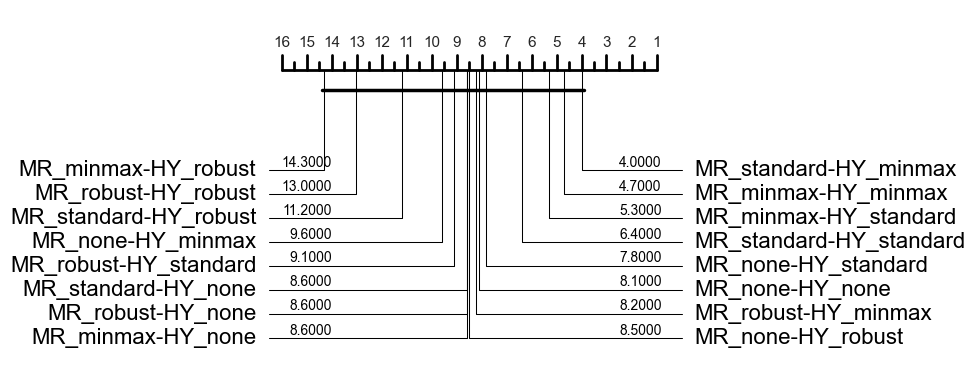

In [43]:
combined_labels = [f"{mr}-{hy}" for mr in col_labels for hy in row_labels]
print(combined_labels)
combined = []
for matrix in matrixes:
    l = []
    for row in matrix:
        for col in row:
            l.append(col)
    combined.append(l)
# combined = np.vstack(matrixes)
plot_critical_difference(combined, combined_labels)

In [44]:
def mr_dual_scaled(X_train_mr, X_test_mr):
    rob = RobustScaler()
    mm = MinMaxScaler()
    X_train_rob = rob.fit_transform(X_train_mr)
    X_test_rob = rob.transform(X_test_mr)

    X_train_mm = mm.fit_transform(X_train_mr)
    X_test_mm = mm.transform(X_test_mr)

    X_train_dual = np.concatenate([X_train_rob, X_train_mm], axis=1)
    X_test_dual  = np.concatenate([X_test_rob, X_test_mm], axis=1)

    return X_train_dual, X_test_dual

In [45]:
def apply_scaler_fit_dualmr(scaler_hy, scaler_mr, x_train, x_test, rand):
    X_train_hy, X_test_hy = hyd_fit(x_train, x_test, rand)
    X_train_mr, X_test_mr = mr_fit(x_train, x_test, rand)

    X_train_hy_scaled = scaler_hy.fit_transform(X_train_hy)
    X_test_hy_scaled = scaler_hy.transform(X_test_hy)
    X_train_mr_scaled, X_test_mr_scaled = mr_dual_scaled(X_train_mr, X_test_mr)

    X_train_f = np.concatenate([X_train_mr_scaled, X_train_hy_scaled], axis=1)
    X_test_f  = np.concatenate([X_test_mr_scaled, X_test_hy_scaled], axis=1)

    return X_train_f, X_test_f

In [ ]:
 def get_acc_matrix_dualmr(x_train, x_test, y_train, y_test):
    scalers = [
        MinMaxScaler(),
        NoScaler(),
        StandardScaler(),
        RobustScaler()
    ]
    n = len(scalers)
    acc_vector = np.zeros(n)
    clf = RidgeClassifierCV()

    for i in range(n):
        x_train_scaled, x_test_scaled = apply_scaler_fit_dualmr(scalers[i], None, x_train, x_test, 42)
        clf.fit(x_train_scaled, y_train)
        preds = clf.predict(x_test_scaled)
        acc_vector[i] = accuracy_score(y_test, preds)

    return acc_vector

In [30]:
matrixes_dualmr = []

start_time = perf_counter()
x_train, y_train = load_arrow_head(split="train")
x_test, y_test = load_arrow_head(split="test")
x_train_p, x_test_p = pad_train_test(x_train, x_test)
matrixes_dualmr.append(get_acc_matrix_dualmr(x_train_p, x_test_p, y_train, y_test))
print("Finished evaluating arrow head dataset in " + str(perf_counter() - start_time) + " seconds.")

# start_time = perf_counter()
# x_train, y_train = load_osuleaf(split="train")
# x_test, y_test = load_osuleaf(split="test")
# x_train_p, x_test_p = pad_train_test(x_train, x_test)
# matrixes_dualmr.append(get_acc_matrix_dualmr(x_train_p, x_test_p, y_train, y_test))
# print("Finished evaluating OSULeaf dataset in " + str(perf_counter() - start_time) + " seconds.")

start_time = perf_counter()
x_train, y_train = load_italy_power_demand(split="train")
x_test, y_test = load_italy_power_demand(split="test")
x_train_p, x_test_p = pad_train_test(x_train, x_test)
matrixes_dualmr.append(get_acc_matrix_dualmr(x_train_p, x_test_p, y_train, y_test))
print("Finished evaluating Italy power demand dataset in " + str(perf_counter() - start_time) + " seconds.")

start_time = perf_counter()
x_train, y_train = load_japanese_vowels(split="train")
x_test, y_test = load_japanese_vowels(split="test")
x_train_p, x_test_p = pad_train_test(x_train, x_test)
matrixes_dualmr.append(get_acc_matrix_dualmr(x_train_p, x_test_p, y_train, y_test))
print("Finished evaluating Japanese vowels dataset in " + str(perf_counter() - start_time) + " seconds.")

# start_time = perf_counter()
# x_train, y_train = load_acsf1(split="train")
# x_test, y_test = load_acsf1(split="test")
# x_train_p, x_test_p = pad_train_test(x_train, x_test)
# matrixes_dualmr.append(get_acc_matrix_dualmr(x_train_p, x_test_p, y_train, y_test))
# print("Finished evaluating acsf1 dataset in " + str(perf_counter() - start_time) + " seconds.")

Finished evaluating arrow head dataset in 65.89357652398758 seconds.


In [32]:
print(matrixes_dualmr)

[array([0.77142857, 0.86285714, 0.78285714, 0.77142857])]


In [ ]:
combined_labels = [f"{mr}-{hy}" for mr in col_labels for hy in row_labels]
print(combined_labels)
combined = []
for matrix in matrixes:
    l = []
    for i, row in enumerate(matrix):
        row.append(matrixes_dualmr[i])
        for col in row:
            l.append(col)
    combined.append(l)
# combined = np.vstack(matrixes)
plot_critical_difference(combined, combined_labels)